### Improving reasoning-with inference time scaling

In [1]:
from pathlib import Path
import sys
import torch

ROOT_DIR = Path.cwd().parent  # Get parent of current directory
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))


from evaluating_reasoning_models.model_and_tokenizer import load_model_and_tokenizer

model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    use_compile=False
)



Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

In [2]:
from evaluating_reasoning_models.generate_text_streams import generate_text_stream_with_kv_cache
from evaluating_reasoning_models.render_prompt import render_prompt


In [3]:
raw_prompt = ("Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?")

prompt = render_prompt(raw_prompt)

print(prompt)

You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Question:
Half the value of $3x-9$ is $x+37$. What is the value of $x$?

Answer:


In [4]:
from evaluating_reasoning_models.complete_boxed import (
    has_complete_boxed_answer,
)


def generate_text_stream_concat_flex(
    model,
    tokenizer,
    prompt,
    device,
    max_new_tokens,
    verbose=False,
    generate_func=None,
    stop_after_boxed=True,
    stop_texts=("\nQuestion:", "\nAnswer:"),
    **generate_kwargs,
):
    if generate_func is None:
        generate_func = generate_text_stream_with_kv_cache

    generated_ids = []
    generated_text = ""

    for token in generate_func(
        prompt=prompt,
        model=model,
        tokenizer=tokenizer,
        device=device,
        max_new_tokens=max_new_tokens,
        eos_token_id=tokenizer.eos_token_id,
        **generate_kwargs,
    ):

        token_id = token.squeeze(0).item()
        generated_ids.append(token_id)

        token_text = tokenizer.decode([token_id])
        generated_text += token_text

        if verbose:
            print(
                token_text,
                end="",
                flush=True,
            )

        if stop_after_boxed and has_complete_boxed_answer(
            generated_text
        ):
            break

        """if stop_texts and any(stop_text in generated_text for stop_text in stop_texts):
            break"""

    return generated_text

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"
response = generate_text_stream_concat_flex(model, 
    tokenizer, 
    prompt, 
    device, 
    max_new_tokens=200, 
    verbose=True, 
    generate_func=generate_text_stream_with_kv_cache)

 \boxed{12}



### Now, using Chain-of-thought prompt ---for better response

In [6]:
prompt_cot = prompt + " \n\nExplain step step by step."

response = generate_text_stream_concat_flex(model, 
    tokenizer, 
    prompt_cot, 
    device, 
    max_new_tokens=700, 
    verbose=True)

:

Step 1: Let $

x$ be the value we are looking for.

Step 2: The problem states that half the value of $3x - 9$ is $x + 37$.

Step 3: So, we can write the equation as $ \frac{1}{2}(3x - 9) = x + 37 $.

Step 4: Multiply both sides of the equation by 2 to eliminate the fraction.

Step 5: $ \frac{1}{2}(3x - 9) \times 2 = (x + 37) \times 2 $.

Step 6: Simplify both sides of the equation.

Step 7: $ 3x - 9 = 2x + 74 $.

Step 8: Subtract $2x$ from both sides to isolate the variable term.

Step 9: $ 3x - 2x - 9 = 2x + 74 - 2x $.

Step 10: Simplify both sides of the equation.

Step 11: $ x - 9 = 74 $.

Step 12: Add 9 to both sides to solve for $x$.

Step 13: $ x = 83 $.

Answer: \boxed{83}


### Controlling output diversity with temperature scaling
* starting with temperature scaling

* ok, now  ---> process of selecting the token

In [7]:
### let's see, how we can get the next token...
prompt_example = "large language models are"
# first will convert the input prompt -> to ids
input_ids = torch.tensor(tokenizer.encode(prompt_example), device=device).unsqueeze(0)

print(input_ids)

tensor([[16767,  4128,  4119,   525]], device='cuda:0')


In [8]:
with torch.inference_mode():
    next_token_logits = model(input_ids,)[:, -1]

print(next_token_logits.shape)  ##  [batch, vocab_size]



torch.Size([1, 151936])


In [9]:
next_token = torch.argmax(next_token_logits)  ## with highest logit score

print(f"This is the token: {tokenizer.decode([next_token])}")
print(f"This is the token id: {next_token}")

This is the token:  trained
This is the token id: 16176


* now let's visualize this, we are not taking entire vocab, but only 100 tokens---> word "trained" is between

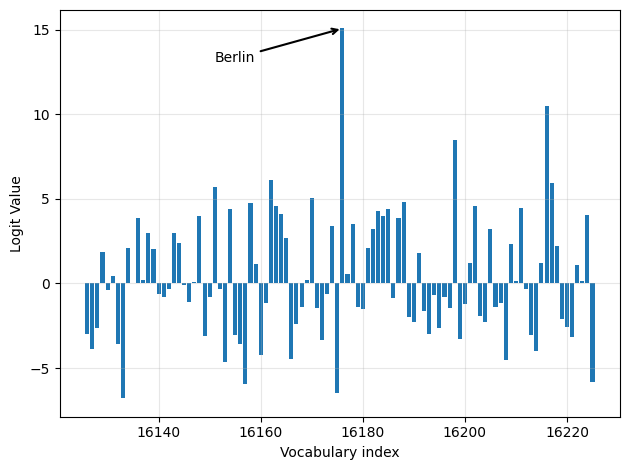

In [10]:
import matplotlib.pyplot as plt

def plot_scores_bar(next_token_logits, start=16126, end=16226, arrow=True, ylabel="Logit Value"):

    ## vocab subsection(instead of all vocab---> use only 100 tokens, to visualize)
    x = torch.arange(start, end)

    # Select logits for the first sequence in the batch and the token IDs
    # in the range [start:end], then convert to float32 and move to CPU. [we have given token in this range of vocab]
    logits_section = next_token_logits[0, start:end].float().cpu()    

    ## plot logits
    plt.bar(x, logits_section)
    plt.xlabel("Vocabulary index")
    plt.ylabel(ylabel)

    # Highlight max logit
    if arrow:
        max_idx = torch.argmax(logits_section)
        plt.annotate(
            "Berlin",
            xy=(x[max_idx], logits_section[max_idx]),
            xytext=(x[max_idx] - 25, logits_section[max_idx] - 2),
            arrowprops={
                "facecolor": "black", "arrowstyle": "->", "lw": 1.5
            },
            fontsize=10,
        )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_scores_bar(next_token_logits)

### Rescaling token scores(logits) with a temperature parameter

In [11]:
def scale_logits_by_temperature(logits, temperature):
    if temperature <= 0:
        raise ValueError("Temperature must be positive")
    return logits / temperature

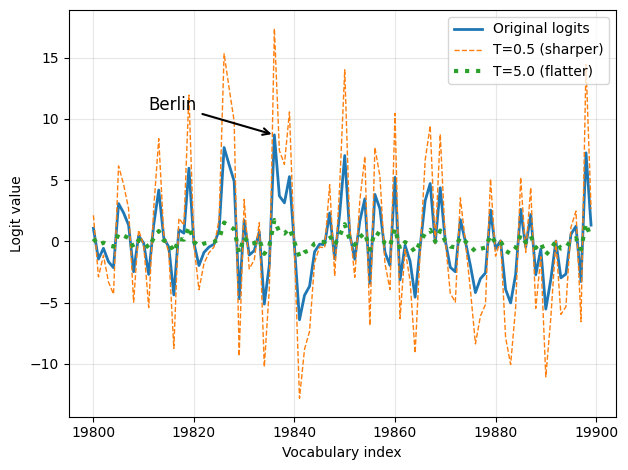

In [12]:
def plot_logits_with_temperature(
    next_token_logits, start=19_800, end=19_900,
    temps=(0.5, 5.0),
):
    x = torch.arange(start, end)
    logits_orig = next_token_logits[0, start:end].float().cpu()

    # Apply temperature scaling
    logits_scaled = [
        scale_logits_by_temperature(logits_orig, T) for T in temps
    ]
    # Plot logits
    plt.plot(x, logits_orig, label="Original logits", lw=2)
    plt.plot(
        x, logits_scaled[0],
        label=f"T={temps[0]} (sharper)", ls="--", lw=1
    )
    plt.plot(
        x, logits_scaled[1],
        label=f"T={temps[1]} (flatter)", ls=":", lw=3
    )

    # Highlight max logit
    max_idx = torch.argmax(logits_orig)
    plt.annotate(
        "Berlin",
        xy=(x[max_idx], logits_orig[max_idx]),
        xytext=(x[max_idx] - 25, logits_orig[max_idx] + 2),
        arrowprops={"facecolor": "black", "arrowstyle": "->", "lw": 1.5},
        fontsize=12,
    )

    plt.xlabel("Vocabulary index")
    plt.ylabel("Logit value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_logits_with_temperature(
    next_token_logits,
    temps=(0.5, 5.0)
)

### Sampling the next token from a probability distribution

In [13]:
# Step 3.2: Rescale next-token scores
rescaled_logits = scale_logits_by_temperature(next_token_logits, 5.0)

# Step 3.3 Convert rescaled logits into probability scores
next_token_probas = torch.softmax(
    rescaled_logits, dim=-1
)

print("Probability sum:", torch.sum(next_token_probas))

Probability sum: tensor(1., device='cuda:0', dtype=torch.bfloat16)


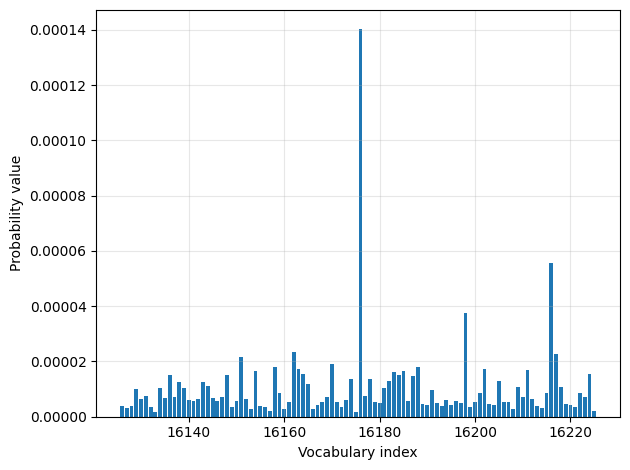

In [14]:
plot_scores_bar(
    next_token_probas, arrow=False, ylabel="Probability value"
)

In [15]:
print("Token ID 19,846 probability:", next_token_probas[:, 19846])

Token ID 19,846 probability: tensor([6.4969e-06], device='cuda:0', dtype=torch.bfloat16)


In [16]:
print("Highest probability:", max(next_token_probas.squeeze(0)))

Highest probability: tensor(0.0001, device='cuda:0', dtype=torch.bfloat16)


In [17]:
# Step 3.4: Sample token according to probabilities
torch.manual_seed(123)
print(
    "Sampled token:",
    torch.multinomial(next_token_probas.cpu(), num_samples=1)
)

Sampled token: tensor([[141943]])


In [18]:
print(tokenizer.decode([65094]))

 mistress


In [19]:
def count_samples(probas, num_samples=1000, threshold=1, tokenizer=None):
    # Draw samples according to probabilities
    samples = torch.multinomial(
        probas.cpu(), num_samples=num_samples, replacement=True
    )
    
    # Count how often each index was selected
    counts = torch.bincount(samples.squeeze(0), minlength=1)
    
    # Print results
    for i, c in enumerate(counts):
        if c > threshold:
            if tokenizer is None:
                print(f"Vocab index {i}: {c.item()}x")
            else:
                print(f"'{tokenizer.decode([i])}': {c.item()}x")

In [20]:
torch.manual_seed(123)
count_samples(next_token_probas, tokenizer=tokenizer)

' the': 2x
' only': 2x
' known': 2x
' namely': 2x
' intensive': 2x
' requestId': 2x
' нам': 2x


In [21]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)

' the': 2x
' not': 4x
' used': 55x
' very': 19x
' being': 14x
' great': 14x
' already': 3x
' able': 4x
' often': 4x
' known': 2x
' currently': 2x
' usually': 2x
' particularly': 2x
' generally': 5x
' becoming': 8x
' typically': 25x
' capable': 21x
' widely': 2x
' trained': 806x
' commonly': 2x


In [22]:
print(probas_lowT[0, 19_846])

tensor(7.8774e-20, device='cuda:0', dtype=torch.bfloat16)


### adding temperature scaling to the text generation function

In [23]:
# Exercise 2.2 Appendix B
from base_model.qwen import KVCache

@torch.inference_mode()
def generate_text_temp_stream_cache(
    model,
    prompt,
    tokenizer,
    device,
    max_new_tokens,
    eos_token_id=None,
    temperature=0.
):

    token_ids = torch.tensor(tokenizer.encode(prompt), device=device).unsqueeze(0)
    
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()

    # Step 3.1: Get logits
    out = model(token_ids, cache=cache)[:, -1]
    for _ in range(max_new_tokens):


        orig_device = token_ids.device

        if temperature is None or temperature == 0.0:
            next_token = torch.argmax(out, dim=-1, keepdim=True)

        else:
            # Step 3.2: Apply temperature scaling on logits
            logits = scale_logits_by_temperature(out, temperature)

            # Step 3.3: Convert to probabilities
            probas = torch.softmax(logits, dim=-1)

            # Step 3.4: Sample token according to probabilities
            next_token = torch.multinomial(probas.cpu(), num_samples=1)
            next_token = next_token.to(orig_device)


        if (eos_token_id is not None
                and torch.all(next_token == eos_token_id)):
            break

        yield next_token
        out = model(next_token, cache=cache)[:, -1]

In [24]:
torch.manual_seed(123)
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_temp_stream_cache,
    temperature=1.1
)

 \boxed{13}



### Balancing diversity and coherence with top-p sampling

* selecting a subset of top-p tokens

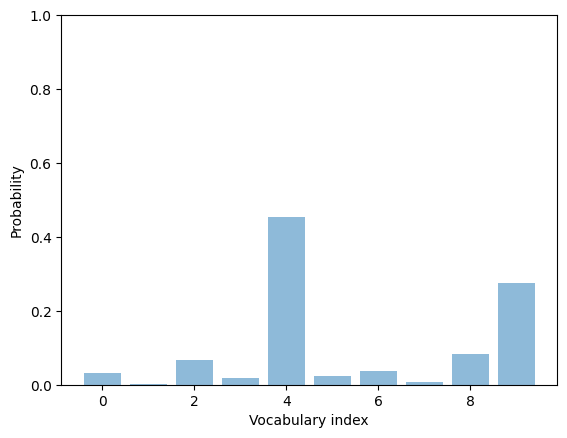

In [25]:
# Step 3.1: Get logits (here: use toy logits for 10 tokens)
toy_logits = torch.tensor(
    [-0.7, -3.0, 0.1, -1.2, 2.0, -1.0, -0.5, -2.0, 0.3, 1.5]
)

# Step 3.2: Apply temperature scaling
toy_logits_scaled = scale_logits_by_temperature(toy_logits, 1.0)

# Step 3.3: Convert to probabilities
toy_probas = torch.softmax(toy_logits_scaled, dim=-1)

plt.bar(
    torch.arange(len(toy_logits_scaled)), toy_probas,
    alpha=0.5
)

plt.ylim([0, 1])
plt.xlabel("Vocabulary index")
plt.ylabel("Probability")
# plt.savefig("12.pdf")
plt.show()

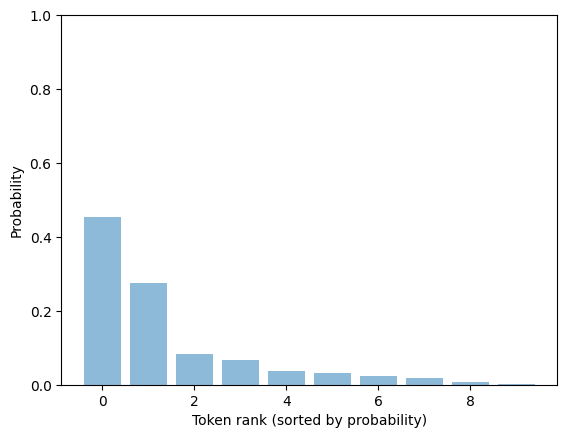

In [26]:

# Step 4.1: Sort by descending probability
sorted_probas, sorted_idx = torch.sort(toy_probas, descending=True)

# Step 4.2: Compute cumulative sum
cumsum = torch.cumsum(sorted_probas, dim=-1)

plt.bar(
    torch.arange(len(sorted_probas)), sorted_probas, 
        alpha=0.5
)


plt.ylim([0, 1])
plt.xlabel("Token rank (sorted by probability)")
plt.ylabel("Probability")
plt.show()

### adding a top-p filter to the text generation function

In [27]:
def top_p_filter(probas, top_p):
    if top_p is None or top_p >= 1.0:
        return probas

    # Step 4.1: Sort by descending probability
    sorted_probas, sorted_idx = torch.sort(probas, dim=1, descending=True)

    # Step 4.2: Cumulative sum
    cumprobas = torch.cumsum(sorted_probas, dim=1)

    # Step 4.3.1: Keep tokens where prefix cumulative mass (before token) is < top_p
    # Example: [0.5, 0.41, 0.09] with top_p=0.9 should keep the first two tokens
    prefix = cumprobas - sorted_probas   # cumulative mass before each token
    keep = prefix < top_p
    # Always keep at least one token (fallback for very small/non-positive top_p)
    keep[:, 0] = True    

    # Step 4.3.2: Zero out beyond cutoff
    kept_sorted = torch.where(
        keep, sorted_probas,
        torch.zeros_like(sorted_probas)
    )
    # Step 4.3.3: Map back to original order
    filtered = torch.zeros_like(probas).scatter(1, sorted_idx, kept_sorted)

    # Step 4.4: Renormalize to sum to 1
    denom = torch.sum(filtered, dim=1, keepdim=True).clamp_min(1e-12)
    return filtered / denom

In [28]:
with torch.inference_mode():
    next_token_logits = model(input_ids)[:, -1]
print(next_token_logits.shape)

torch.Size([1, 151936])


In [29]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)

' the': 2x
' not': 4x
' used': 55x
' very': 19x
' being': 14x
' great': 14x
' already': 3x
' able': 4x
' often': 4x
' known': 2x
' currently': 2x
' usually': 2x
' particularly': 2x
' generally': 5x
' becoming': 8x
' typically': 25x
' capable': 21x
' widely': 2x
' trained': 806x
' commonly': 2x


In [30]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.39), dim=-1
)
probas_lowT_filtered = top_p_filter(probas_lowT, top_p=0.8)

count_samples(probas_lowT_filtered, threshold=1, tokenizer=tokenizer)

' used': 96x
' typically': 45x
' trained': 859x


In [31]:
@torch.inference_mode()
def generate_text_top_p_stream_cache(
    model,
    prompt,
    tokenizer, 
    device,
    max_new_tokens,
    eos_token_id=None,
    temperature=0.,
    top_p=None
):

    token_ids = torch.tensor(tokenizer.encode(prompt), device=device).unsqueeze(0)
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()

    

    # Step 3.1: Get logits
    out = model(token_ids, cache=cache)[:, -1]
    for _ in range(max_new_tokens):

        orig_device = token_ids.device

        if temperature is None or temperature == 0.0:
            next_token = torch.argmax(out, dim=-1, keepdim=True)

        else:
            # Step 3.2: Apply temperature scaling on logits
            logits = scale_logits_by_temperature(out, temperature)

            # Step 3.3: Convert to probabilities
            probas = torch.softmax(logits, dim=-1)

            # (New) Step 4: Apply top-p filter to probabilities
            probas = top_p_filter(probas, top_p)            

            # Step 3.4: Sample token according to probabilities
            next_token = torch.multinomial(probas.cpu(), num_samples=1)
            next_token = next_token.to(orig_device)

        if (eos_token_id is not None
                and torch.all(next_token == eos_token_id)):
            break

        yield next_token
        out = model(next_token, cache=cache)[:, -1]

In [32]:
torch.manual_seed(123)
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.5,
    top_p=0.8, 
)

 \boxed{12}



### Improving response accuracy with self-consistency

In [33]:
# in this technique, we will ---> sample multiple reasoning traces
# with high-temperature and top-p, ---> then extract the final answer from each chain
# chooses the most frequent final answer

from evaluating_reasoning_models.final_candidate import extract_final_candidate
from collections import Counter

def self_consistency_vote(
    model, tokenizer, prompt, device,
    num_samples=10, temperature=0.8, top_p=0.9,
    max_new_tokens=2048, show_progress=True, show_long_answer=False, seed=None):

    full_answers, short_answers = [], []

    # sample multiple answers
    for i in range(num_samples):
        if seed is not None:
            torch.manual_seed(seed + i + 1)

        answer = generate_text_stream_concat_flex(
            model=model, tokenizer=tokenizer, prompt=prompt,
            device=device, max_new_tokens=max_new_tokens, verbose=show_long_answer,
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature, top_p=top_p
        )

        # extract the final (short) answer from each answer
        short = extract_final_candidate(answer, fallback="number_then_full")

        full_answers.append(answer)
        short_answers.append(short)

        if show_progress:
            print(f"[Sample {i+1}/{num_samples}] -> {short!r}")

    ## choose the most frequent final answer (self-consistency vote)
    counts = Counter(short_answers)

    groups = {s: [] for s in counts}

    for idx, s in enumerate(short_answers):
        groups[s].append(idx)   ## adding indexes to list, where value appears

    mc = counts.most_common()  ## this will store the frequency count --> that how many times each value appears like [("42", 6)]

    if not mc:
        majority_winners, final_answer = [], None

    else:
        top_freq = mc[0][1]
        majority_winners = [s for s, f in mc if f == top_freq]
        final_answer = mc[0][0] if len(majority_winners) == 1 else None

    return {
        "full_answers": full_answers,
        "short_answers": short_answers,
        "counts": dict(counts),
        "groups": groups,
        "majority_winners": majority_winners,
        "final_answer": final_answer
    }

* notes from raschka's notebook
- if all (long) answers look nearly identical, increase temperature gently to increase diversity
- if (long) answers look off, decrease temperature

In [34]:
results = self_consistency_vote(
    model, tokenizer,
    prompt, device=device,
    num_samples=7, temperature=0.8,
    top_p=0.9, max_new_tokens=2048,
    seed=123, show_progress=True,
)

[Sample 1/7] -> '10'
[Sample 2/7] -> '13'
[Sample 3/7] -> '22'
[Sample 4/7] -> '12'
[Sample 5/7] -> '14'
[Sample 6/7] -> '19'
[Sample 7/7] -> '12'


In [35]:
print(results["final_answer"])

12


In [36]:
print(results["full_answers"])

[' \\boxed{10}\n\n', ' \\boxed{13}\n', ' \\boxed{22}\n\n', ' \\boxed{12}\n\n', ' \\boxed{14}\n\n', ' \\boxed{19}\n\n', ' \\boxed{12}\n\n']


In [37]:

results = self_consistency_vote(
    model, tokenizer,
    prompt + "\n\nExplain step by step.",  ## using chain-of-thought
    device=device,
    num_samples=7, temperature=0.8,
    top_p=0.9, max_new_tokens=2048,
    seed=123, show_progress=True
)

[Sample 1/7] -> 'ANSWER'
[Sample 2/7] -> '12'
[Sample 3/7] -> 'ANSWER'
[Sample 4/7] -> '23'
[Sample 5/7] -> '3x - 9 = x + 37'
[Sample 6/7] -> 'ANSWER'
[Sample 7/7] -> '25'


* here used temperature=0.8, and in "text_generation" function stop texts was enabled...
* model was giving some garbage output-->

In [38]:

results = self_consistency_vote(
    model, tokenizer,
    prompt + "\n\nExplain step by step.",  ## using chain-of-thought
    device=device,
    num_samples=7, temperature=0.5,
    top_p=0.9, max_new_tokens=2048,
    seed=123, show_progress=True
)

[Sample 1/7] -> '83'
[Sample 2/7] -> '23'
[Sample 3/7] -> '83'
[Sample 4/7] -> '83'
[Sample 5/7] -> '83'
[Sample 6/7] -> '83'
[Sample 7/7] -> '83'


In [39]:
print(results["full_answers"][0])   ## after commenting the stop_answeer --- code in text_generation function

:

Step 1: The problem states that half the value of $3x - 9$ is $x + 37$. So, we can write this as an equation: $\frac{1}{2}(3x - 9) = x + 37$.

Step 2: To solve for $x$, we can multiply both sides of the equation by 2 to eliminate the fraction: $3x - 9 = 2x + 74$.

Step 3: Now, we can simplify the equation by subtracting $2x$ from both sides: $x - 9 = 74$.

Step 4: Adding 9 to both sides gives us $x = 83$.

Answer:

\boxed{83}



### Self-Consistency Decoding

Used **Chain of Thought (CoT)** prompting so the model explains its reasoning step by step before producing the final answer.

**Issue:** The generation was stopping too early because of:

```python
if stop_texts and any(stop_text in generated_text for stop_text in stop_texts):
    break
```

I temporarily commented it out, which allowed the model to generate the complete reasoning trace and the full `\boxed{...}` answer.

**Temperature tuning:** With `temperature=0.8`, the model produced many noisy and inconsistent answers. I reduced it to `0.5`, which made the generations more stable while still preserving diversity.

**Result:** After using CoT reasoning, disabling premature stopping, and lowering the temperature, the self-consistency vote successfully converged on the correct answer, with the majority answer appearing **6 times**.

### now going to evaluate

* we will do couple of runs...
 - COT ---> base, reasoning
 - temperature and top-p ---> base, reasoning
 - temperature + top-p, + self consistency(n=5) ---> base, reasoning
 - temperature + self-consistency(n=5) + top-p + CoT  ---> base, reasoning

In [51]:
from evaluating_reasoning_models.load_math_500 import load_math500_test

math_data = load_math500_test()

In [53]:
math_data[0]

{'problem': 'Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\\theta),$ where $r > 0$ and $0 \\le \\theta < 2 \\pi.$',
 'solution': 'We have that $r = \\sqrt{0^2 + 3^2} = 3.$  Also, if we draw the line connecting the origin and $(0,3),$ this line makes an angle of $\\frac{\\pi}{2}$ with the positive $x$-axis.\n\n[asy]\nunitsize(0.8 cm);\n\ndraw((-0.5,0)--(3.5,0));\ndraw((0,-0.5)--(0,3.5));\ndraw(arc((0,0),3,0,90),red,Arrow(6));\n\ndot((0,3), red);\nlabel("$(0,3)$", (0,3), W);\ndot((3,0), red);\n[/asy]\n\nTherefore, the polar coordinates are $\\boxed{\\left( 3, \\frac{\\pi}{2} \\right)}.$',
 'answer': '\\left( 3, \\frac{\\pi}{2} \\right)',
 'subject': 'Precalculus',
 'level': 2,
 'unique_id': 'test/precalculus/807.json'}

* so, first run will be --> run CoT ---> on base, reasoning 

In [58]:
from evaluating_reasoning_models.evaluating_reasoning_models import evaluate_math500_stream

which_model="base"

print("Model:", which_model)
print("Device:", device)

## evaluation function
num_correct, num_examples, acc = evaluate_math500_stream(model, tokenizer, device, math_data[:20], max_new_tokens=2048, verbose=False)





Model: base
Device: cuda
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/IPython/core/interactiveshell.py", line 3548, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_3291/602165999.py", line 9, in <module>
    num_correct, num_examples, acc = evaluate_math500_stream(model, tokenizer, device, math_data[:20], max_new_tokens=2048, verbose=False)
                                     ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/teamspace/studios/this_studio/open-posttraining-system/evaluating_reasoning_models/evaluating_reasoning_models.py", line 456, in evaluate_math500_stream
  File "/teamspace/studios/this_studio/open-posttraining-system/evaluating_reasoning_models/evaluating_reasoning_models.py", line 61, in generate_text_stream_concat
    if eos_token_id is not None and torch.all(next_token == eos_token_id):
             ^^^^^^^^^^^^^^^^^^^^^^